# Preparação do ambiente
Importa as bibliotecas necessárias para manipulação de dados com `pandas`, visualização com `matplotlib` e modelagem com `scikit-learn`.


In [49]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import matthews_corrcoef

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Leitura do conjunto de dados
Carrega o arquivo `data/DS_BALANCEADO.CSV` em um DataFrame e exibe as primeiras linhas para validar a estrutura e as colunas disponíveis.


In [50]:
df = pd.read_csv("../data/DS_BALANCEADO.CSV")

df.head()

,Tempo_Conta,Uso_Semanal,Satisfacao,Tempo_Resposta_Suporte,Cancelou
0,Novo,Baixo,Baixa,48,Sim
1,Novo,Medio,Media,24,Nao
2,Novo,Alto,Alta,12,Nao
3,Antigo,Baixo,Baixa,72,Sim
4,Antigo,Medio,Media,24,Nao


# Verificação da variável alvo
Mostra a distribuição da coluna `Cancelou` para identificar como as classes estão balanceadas e verificar os possíveis valores da variável resposta.


In [51]:
df["Cancelou"].value_counts()

Cancelou
Nao    7
Sim    5
Name: count, dtype: int64

# Separação de atributos e alvo
Cria `X` com os atributos de entrada e `y` com a variável de saída `Cancelou`, preparando os dados para modelagem.


In [52]:
X = df.drop(columns=["Cancelou"])
y = df["Cancelou"]

print(X.head())
print(y.head())

  Tempo_Conta Uso_Semanal Satisfacao  Tempo_Resposta_Suporte
0        Novo       Baixo      Baixa                      48
1        Novo       Medio      Media                      24
2        Novo        Alto       Alta                      12
3      Antigo       Baixo      Baixa                      72
4      Antigo       Medio      Media                      24
0    Sim
1    Nao
2    Nao
3    Sim
4    Nao
Name: Cancelou, dtype: str


# Identificação de tipos de dados
Detecta automaticamente as colunas categóricas e numéricas para aplicar transformações apropriadas em cada tipo de dado.


In [53]:
colunas_categoricas = X.select_dtypes(
    include=["object", "string", "category"]
).columns
colunas_numericas = X.select_dtypes(exclude=["object"]).columns

preprocessador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas),
        ("num", "passthrough", colunas_numericas)
    ]
)

# Configuração do pré-processamento
Prepara o pipeline de transformação com `OneHotEncoder` para variáveis categóricas e mantém as variáveis numéricas inalteradas.


In [54]:
arvore = DecisionTreeClassifier(random_state=42)

modelo = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("arvore", arvore)
])

# Criação do pipeline de modelagem
Define o pipeline que integra o pré-processamento e o classificador `DecisionTreeClassifier` em uma única sequência de execução.


In [55]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

y_pred = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv
)

y_proba = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

# Validação cruzada estratificada
Executa validação cruzada com 3 folds para gerar previsões de classe e probabilidades sem viés de divisão de teste/training.


In [56]:
modelo.fit(X, y)

classes = list(modelo.classes_)
indice_sim = classes.index("Sim")

y_score_sim = y_proba[:, indice_sim]
y_binario = (y == "Sim").astype(int)

print("AUC:", round(roc_auc_score(y_binario, y_score_sim), 3))
print("Accuracy:", round(accuracy_score(y, y_pred), 3))
print("F1-score:", round(f1_score(y, y_pred, average="weighted"), 3))
print("Precision:", round(precision_score(y, y_pred, average="weighted"), 3))
print("Recall:", round(recall_score(y, y_pred, average="weighted"), 3))
mcc = matthews_corrcoef(y, y_pred)

print("MCC:", round(mcc, 3))

AUC: 0.9
Accuracy: 0.917
F1-score: 0.915
Precision: 0.927
Recall: 0.917
MCC: 0.837


# Avaliação de desempenho
Ajusta o modelo em todo o conjunto de dados e calcula métricas de desempenho chave, incluindo AUC, acurácia, F1, precisão, recall e MCC.


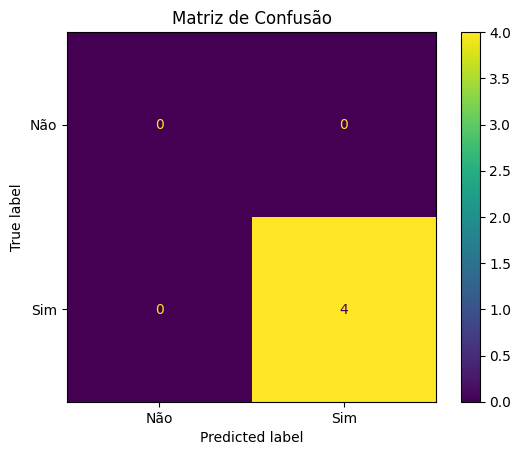

In [57]:
cm = confusion_matrix(
    y,
    y_pred,
    labels=["Não", "Sim"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Não", "Sim"]
)

disp.plot()

plt.title("Matriz de Confusão")
plt.show()

# Matriz de confusão
Plota a matriz de confusão para analisar acertos e erros do modelo nas classes `Não` e `Sim`.


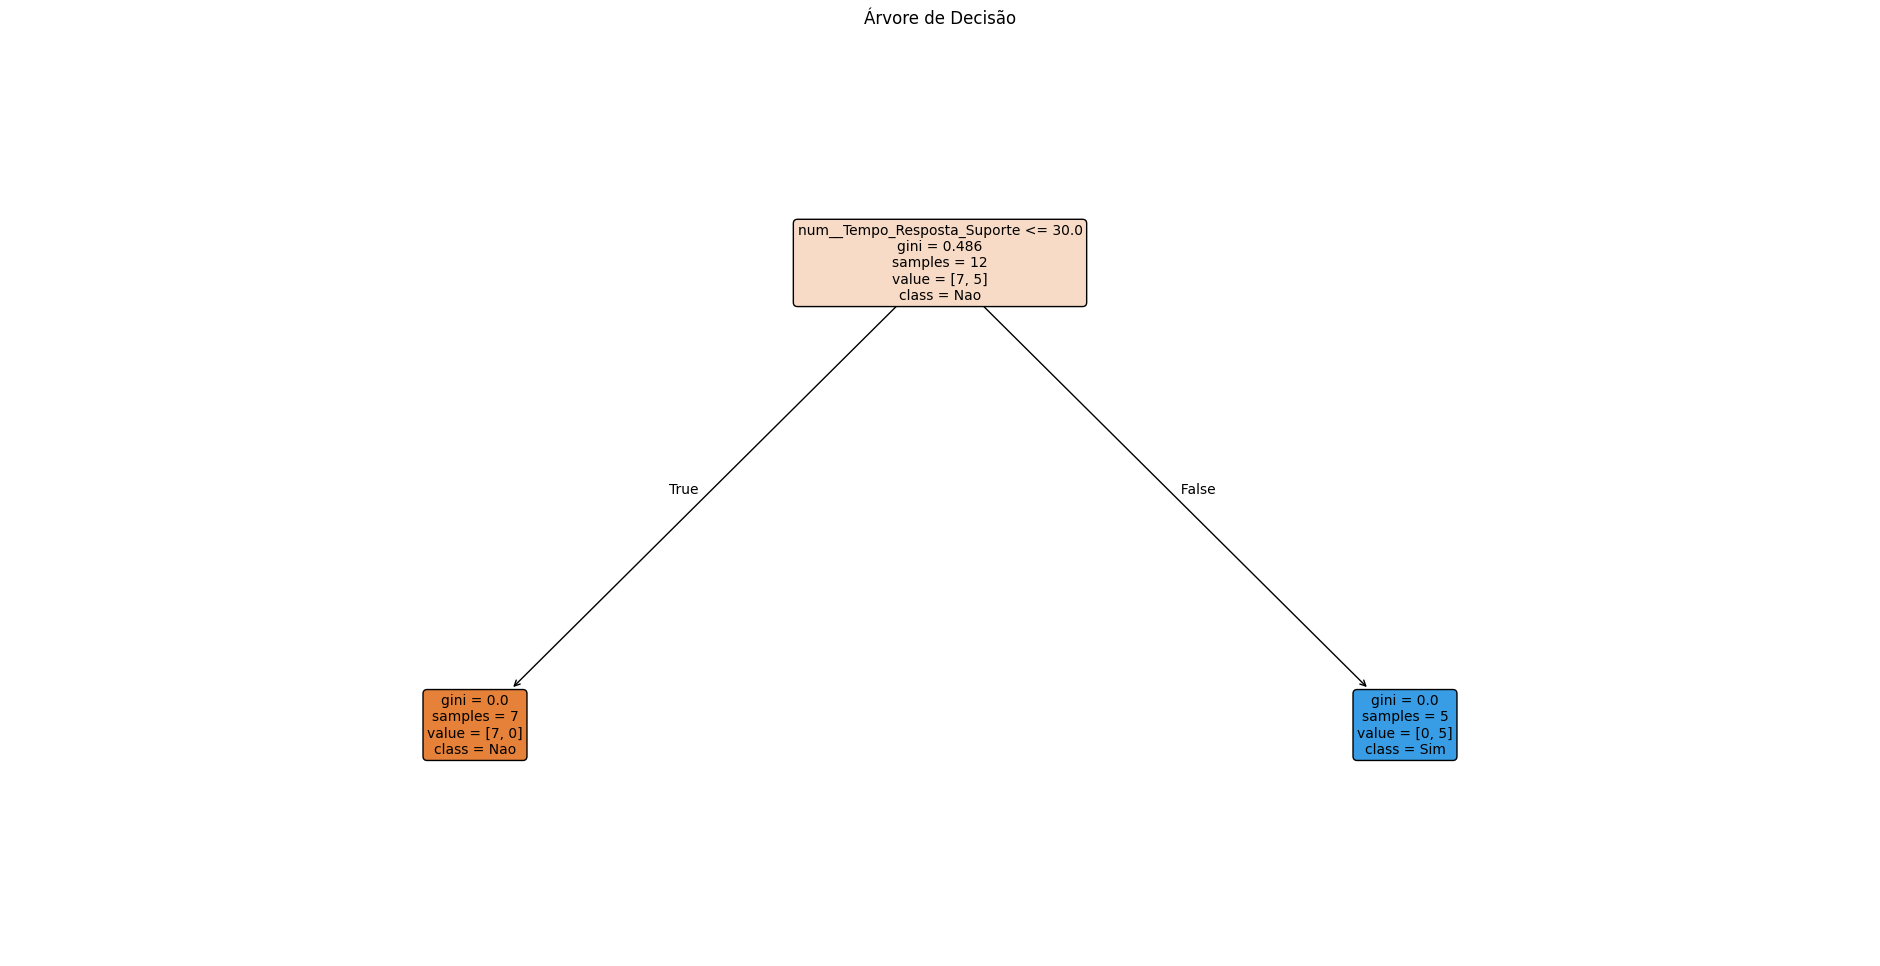

In [58]:
feature_names = modelo.named_steps[
    "preprocessador"
].get_feature_names_out()

arvore_treinada = modelo.named_steps["arvore"]

plt.figure(figsize=(24, 12))

plot_tree(
    arvore_treinada,
    feature_names=feature_names,
    class_names=arvore_treinada.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árvore de Decisão")

plt.show()

# Visualização da árvore
Desenha a árvore de decisão treinada com rótulos de características e classes, facilitando a interpretação das regras aprendidas pelo modelo.
